## The Decision Tree Model

Decision Tree model. It is one of the simplest nonlinear machine learning models.

It all starts with a dataset in which you have a target variable and multiple explanatory variables. Now a huge number of splits are possible, but you need to choose 
one. The first split should be the split that would obtain `the lowest Mean Squared Error`. In the end, even a model with only one split would be able to be used as a predictive 
model.

We’ll be working with data that come from a bike-sharing company. We can download the data from the UCI machine learning archives over here: ***`https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset`***.
This will be a difficult example. In this dataset, we’ll be predicting the number of rental bike users per day. And this will depend strongly on the weather. The weather is hard to predict, and if our forecast has a strong correlation with the weather, it will be a big challenge.

In [1]:
#nImport the bike data
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('../database/bike+sharing+dataset/day.csv')
data

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


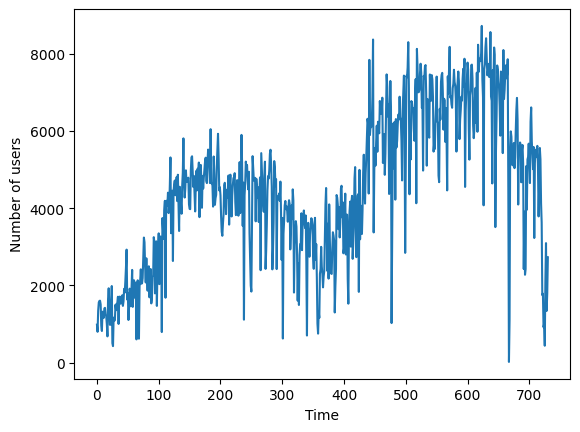

In [2]:
ax = data['cnt'].plot()
ax.set_ylabel('Number of users')
ax.set_xlabel('Time')
plt.show()

There is a difficult trend to be estimated. There is also a lot of day-to-day variation. When we look at the dataset, 
we can see that there are a lot of data on weather. This is going to be the challenge: the number of bike-sharing users depends strongly on the day’s weather, but the weather is 
not something that we can know in advance.

The only thing you can do in such cases is to try and do a lot of feature engineering to create many valuable variables for the model.

The total list of explanatory values is as follows:
* Original variable ‘season’: (1:spring, 2:summer, 3:fall, 4:winter)
* Original variable ‘yr’: The year
* Original variable ‘mnth’: The month
* Original variable ‘holiday’: Whether the day is a holiday
* Original variable ‘weekday’: The day of the week
* Original variable ‘workingday’: Whether the day is a holiday/weekend or a working day
* The 7 last days of ‘cnt’: An autoregressive component for the number of users
* The 7 last days of ‘weathersit’: The weather, from 4 (very bad weather) to 1 (good weather)
* The 7 last days of ‘temperature’
* The 7 last days of ‘humidity’

We also have to deal with outliers in the train dataset as it affects the training negatively but we wont do that in the test so that the model can be tested with real world information.

In [3]:
# Creating the training dataset

# 7 last days of user count (autoregression)
data['usersL1'] = data['cnt'].shift(1)
data['usersL2'] = data['cnt'].shift(2)
data['usersL3'] = data['cnt'].shift(3)
data['usersL4'] = data['cnt'].shift(4)
data['usersL5'] = data['cnt'].shift(5)
data['usersL6'] = data['cnt'].shift(6)
data['usersL7'] = data['cnt'].shift(7)
# 7 last days of weathersit
data['weatherL1'] = data['weathersit'].shift(1)
data['weatherL2'] = data['weathersit'].shift(2)
data['weatherL3'] = data['weathersit'].shift(3)
data['weatherL4'] = data['weathersit'].shift(4)
data['weatherL5'] = data['weathersit'].shift(5)
data['weatherL6'] = data['weathersit'].shift(6)
data['weatherL7'] = data['weathersit'].shift(7)
# 7 last days of temperature
data['tempL1'] = data['temp'].shift(1)
data['tempL2'] = data['temp'].shift(2)
data['tempL3'] = data['temp'].shift(3)
data['tempL4'] = data['temp'].shift(4)
data['tempL5'] = data['temp'].shift(5)
data['tempL6'] = data['temp'].shift(6)
data['tempL7'] = data['temp'].shift(7)
# 7 last days of humidity
data['humL1'] = data['hum'].shift(1)
data['humL2'] = data['hum'].shift(2)
data['humL3'] = data['hum'].shift(3)
data['humL4'] = data['hum'].shift(4)
data['humL5'] = data['hum'].shift(5)
data['humL6'] = data['hum'].shift(6)
data['humL7'] = data['hum'].shift(7)

In [4]:
data = data.dropna()
data = data.drop(477)
data

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,...,tempL5,tempL6,tempL7,humL1,humL2,humL3,humL4,humL5,humL6,humL7
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,...,0.196364,0.363478,0.344167,0.498696,0.518261,0.436957,0.590435,0.437273,0.696087,0.805833
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,...,0.200000,0.196364,0.363478,0.535833,0.498696,0.518261,0.436957,0.590435,0.437273,0.696087
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,...,0.226957,0.200000,0.196364,0.434167,0.535833,0.498696,0.518261,0.436957,0.590435,0.437273
10,11,2011-01-11,1,0,1,0,2,1,2,0.169091,...,0.204348,0.226957,0.200000,0.482917,0.434167,0.535833,0.498696,0.518261,0.436957,0.590435
11,12,2011-01-12,1,0,1,0,3,1,1,0.172727,...,0.196522,0.204348,0.226957,0.686364,0.482917,0.434167,0.535833,0.498696,0.518261,0.436957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,...,0.265833,0.326667,0.330000,0.823333,0.734783,0.791304,0.515417,0.441250,0.556667,0.667917
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,...,0.245833,0.265833,0.326667,0.652917,0.823333,0.734783,0.791304,0.515417,0.441250,0.556667
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,...,0.231304,0.245833,0.265833,0.590000,0.652917,0.823333,0.734783,0.791304,0.515417,0.441250
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,...,0.291304,0.231304,0.245833,0.752917,0.590000,0.652917,0.823333,0.734783,0.791304,0.515417


In [5]:
# Independent and Dependent Variables
X = data[['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday','weatherL1', 'weatherL2', 'weatherL3','weatherL4', 'weatherL5', 'weatherL6', 'weatherL7',
'usersL1','usersL2', 'usersL3', 'usersL4', 'usersL5', 'usersL6','usersL7','tempL1', 'tempL2', 'tempL3', 'tempL4', 'tempL5', 'tempL6', 'tempL7','humL1', 'humL2','humL3', 'humL4', 'humL5', 'humL6', 'humL7']]
y = data['cnt']

In [10]:
# Fitting the model

# Create Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20,random_state=12345, shuffle=False)

from sklearn.tree import DecisionTreeRegressor

my_dt = DecisionTreeRegressor(random_state=12345)
my_dt.fit(X_train, y_train)

from sklearn.metrics import r2_score

print(r2_score(list(y_train), list(my_dt.predict(X_train))))
print(r2_score(list(y_test), list(my_dt.predict(X_test))))

1.0
0.16582718614044134


This is a case of overfitting as we didn't try to optimize with hyperparameter tuning.

There are many hyperparameters. In this case we will just tune the following with grid search:

* min_samples_split: The minimum number of samples required to split a node. Higher values make for fewer splits. Having fewer splits makes a tree less specific, so this can help to prevent overfitting.

* max_features: The number of features (variables) to consider when searching the best split. When using fewer features, you force the splits to be different from each other, but at the same time, you can be blocking the tree from finding the split that is actually the best split.

* Error criterion: As we’re optimizing our R2, we would potentially want to use the R2 as an error criterion for the decision of the best splits. Yet it is not available. It can therefore be interesting to try the MSE and the MAE and see which one allows us to optimize the R2 of the complete tree.

In [11]:
# Adding a grid search
from sklearn.model_selection import GridSearchCV

params={'min_samples_split': list(range(20,50, 2)),
'max_features': [0.6, 0.7, 0.8, 0.9, 1.],
'criterion': ['absolute_error', 'squared_error', 'poisson']}

dt_model=DecisionTreeRegressor(random_state=44)

my_dt = GridSearchCV(estimator=dt_model,param_grid=params,
scoring = 'r2', n_jobs = -1)
my_dt.fit(X_train, y_train)

print("train score: ",r2_score(list(y_train), list(my_dt.predict(X_train))))
print("test score: ",r2_score(list(y_test), list(my_dt.predict(X_test))))

train score:  0.8383874375382655
test score:  0.5545378076277191


Much better training score in relation to the test score. The test performance is still not acceptable.

In [12]:
#Finding the best parameters. This will show you the best parameters as follows:
print(my_dt.best_estimator_)


DecisionTreeRegressor(criterion='absolute_error', max_features=0.8,
                      min_samples_split=48, random_state=44)


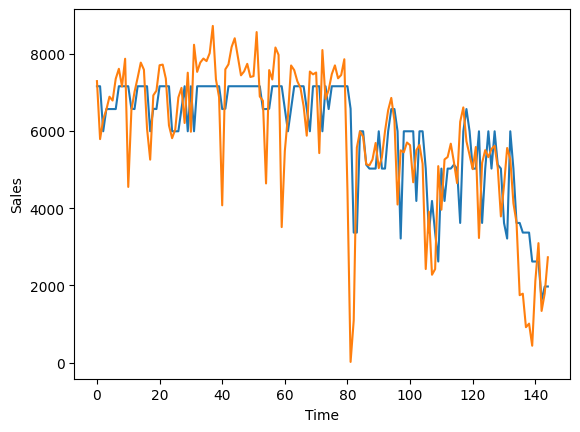

In [13]:
# Plotting the prediction
fcst = my_dt.predict(X_test)

# Plot
plt.plot(list(fcst))
plt.plot(list(y_test))
plt.ylabel('Sales')
plt.xlabel('Time')
plt.show()

We will view a plot that shows you the different splits that have been identified. This type of plot is sometimes also referred to as a dendrogram.

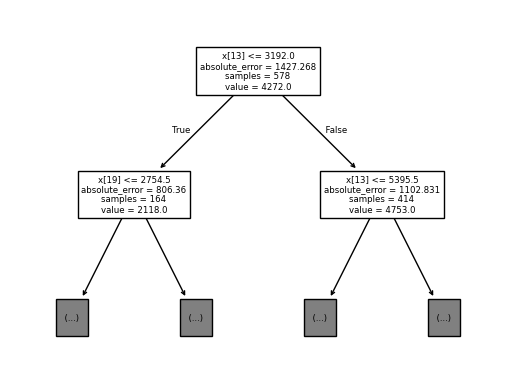

In [14]:
# Plotting the dendrogram

from sklearn.tree import plot_tree
plot_tree(my_dt.best_estimator_, max_depth=1)
plt.show()

### Key Takeaways
* The Decision Tree model is one of the simplest nonlinear supervised machine learning models.
* You can tune the complexity of the decision tree, which defines how long and complex a decision tree becomes.
* Complex trees risk overfitting: they learn too detailed patterns in the training data. You can use a grid search to optimize the complexity of the tree.
* You can create a dendrogram of the fitted decision tree to obtain all the splits and variables that have been used by your model.